# Exploration of the $gg \to (h^{\ast} \to) ZZ \to 4\ell$ dataset

In this tutorial, we will take some time to explore & understand the phenomenology of the off-shell Higgs production.

In [1]:
# import the packages
import pandas as pd
import numpy as np
import vector
import hist

from physics.simulation import mcfm
from physics.analysis import zz4l, zz2l2v
from physics.hstar import sigstr
from nsbi import carl

import matplotlib, matplotlib.pyplot as plt

## 0. Open the dataset

Use the `mcfm.from_csv(file_path=..., kinematics=...)` function to open three datasets generated according to the different hypotheses:

1. Signal-only: $|\mathcal{M}_{gg \to h^{\ast} \to ZZ}|^2$.
2. Background-only: $|\mathcal{M}_{gg \to ZZ}|^2$.
3. Signal+background+interference: $|\mathcal{M}_{gg \to (h^{\ast} \to) ZZ}|^2$.

Open the corresponding datasets, remember to explicitly specify the 4-lepton observables, $x$, to be read out from each event.

In [2]:
features_4l = ['l1_pt', 'l1_eta', 'l1_phi', 'l1_energy', 
               'l2_pt', 'l2_eta', 'l2_phi', 'l2_energy', 
               'l3_pt', 'l3_eta', 'l3_phi', 'l3_energy', 
               'l4_pt', 'l4_eta', 'l4_phi', 'l4_energy']

data_path = '/global/cfs/cdirs/m5295/NSBIData/h4l_data/sm/'

events_sig = mcfm.from_csv(file_path = data_path +  'ggzz4l_sig.csv', kinematics = features_4l)
events_bkg = mcfm.from_csv(file_path = data_path +  'ggzz4l_bkg.csv', kinematics = features_4l)
events_sbi = mcfm.from_csv(file_path = data_path +  'ggzz4l_sbi.csv', kinematics = features_4l)

## 1. Basic histogramming

As with many HEP analyses, we begin by visuzalizing kinematic distributions using histograms. We will be using the `hist` package to: 

1. Define a histogram with 20 bins from $0 \leq p_{\rm T} < 200\, \rm GeV$.
2. Fill it with the leading lepton $p_{\rm T}^{\ell_1}$ as the observable, with weights.

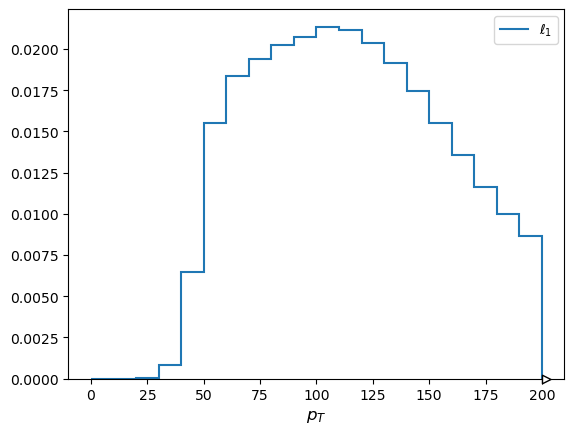

In [3]:
l1pt_axis = hist.axis.Regular(20, 0, 200, label = 'l1pt')
h_l1pt_sig = hist.Hist(l1pt_axis)
h_l1pt_bkg = hist.Hist(l1pt_axis)
h_l1pt_sbi = hist.Hist(l1pt_axis)

h_l1pt_sig.fill( events_sig.kinematics['l1_pt'], weight = events_sig.weights )
h_l1pt_bkg.fill( events_bkg.kinematics['l1_pt'], weight = events_bkg.weights )
h_l1pt_sbi.fill( events_sbi.kinematics['l1_pt'], weight = events_sbi.weights )

fig, ax = plt.subplots()

h_l1pt_sig.plot(ax=ax)
ax.set_xlabel(r'$p_T$', fontsize=12)
ax.legend([r'$\ell_1$'])

**Exercise**:

Drawing from the above example, use the cell below to try plotting various kinematics. Try plotting the same kinematic across different objects

In [4]:
#### USE ME TO PLOT THINGS ####




**Question for participants**
1. What, if any, interesting features did you find?
1. Naively, what kinematics would you expect to be more or less informative

## 2. Custom observable calculation: $m_{4\ell}$

Recall that the Lorentz invariant mass of a four-momentum is given by.

$$
m = \sqrt{E^2 - |{\bf{p}}|^2}.
$$

The four-vector $p$ can represent that of any of the 4 leptons, or that of the entire 4-lepton system:

$$
    m_{4\ell} = \sqrt{\left(\sum_i E_i\right)^2 - \left|\sum_i {\bf p_i}\right|^2}
$$

Let's compute this quantity using the convenient four-vector arithmetics provicded by the `vector` package. You can check your results with the correct values already saved in the event kinematics.


In [5]:
def calculate_m4l(kinematics):
    p_l1 = vector.array({'pt': kinematics['l1_pt'], 'eta': kinematics['l1_eta'], 'phi': kinematics['l1_phi'], 'energy': kinematics['l1_energy']})
    p_l2 = vector.array({'pt': kinematics['l2_pt'], 'eta': kinematics['l2_eta'], 'phi': kinematics['l2_phi'], 'energy': kinematics['l2_energy']})
    p_l3 = vector.array({'pt': kinematics['l3_pt'], 'eta': kinematics['l3_eta'], 'phi': kinematics['l3_phi'], 'energy': kinematics['l3_energy']})
    p_l4 = vector.array({'pt': kinematics['l4_pt'], 'eta': kinematics['l4_eta'], 'phi': kinematics['l4_phi'], 'energy': kinematics['l4_energy']})
    return (p_l1 + p_l2 + p_l3 + p_l4).mass

Now we histogram the 4-lepon invariant mass! Use a uniform $20\,\rm GeV$-wide bins, $180 \leq m_{4\ell} < 1000\, \rm GeV$.

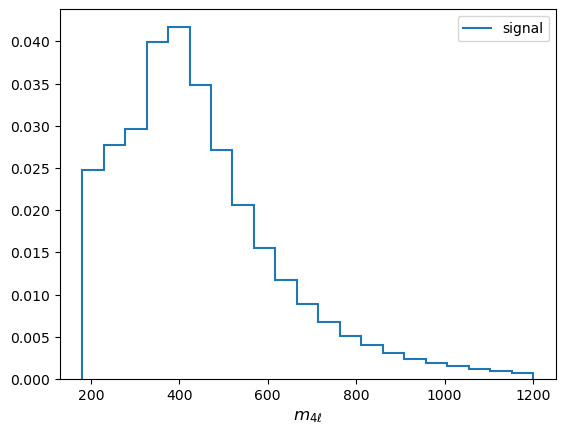

In [6]:
m4l_axis = hist.axis.Regular(21, 180, 1200, label = 'm4l')
h_m4l_sig = hist.Hist(m4l_axis)
h_m4l_bkg = hist.Hist(m4l_axis)
h_m4l_sbi = hist.Hist(m4l_axis)

h_m4l_sig.fill( calculate_m4l(events_sig.kinematics), weight = events_sig.weights )
h_m4l_bkg.fill( calculate_m4l(events_bkg.kinematics), weight = events_bkg.weights )
h_m4l_sbi.fill( calculate_m4l(events_sbi.kinematics), weight = events_sbi.weights )

fig, ax = plt.subplots()

h_m4l_sig.plot(ax=ax)
ax.set_xlabel(r'$m_{4\ell}$', fontsize=12)
ax.legend(['signal'])

**Exercise**:

Drawing from the above example, use the cell below to plot $m_{4\ell}$ for all three distributions. Try modifying the binning and the axis scaling

In [7]:
#### USE ME TO PLOT THINGS ####




**Questions for participants**
1. What interesting features did you find about these distributions?
1. Using this visualization, how do you expect the interference between signal and background to behave? Will it be positive or negative? 

## 3. Inteference-only contribution

Obtain the $m_{4\ell}$ distribution corresponding to the interference-only hypothesis:

$$
 \left| \mathcal{M}_{\rm S} + \mathcal{M}_{\rm B} \right|^2 = |\mathcal{M}_{\rm S}|^2 + {\color{orange}2\mathbb{R} ( \mathcal{M}^{\dagger}_{\rm S} \mathcal{M}_{\rm B} )}  + \left| \mathcal{M}_{\rm B} \right|^2
$$

Note that the only term not included in the above three datasets is the term in orange. 

Text(0.5, 0, '$m_{4\\ell}$')

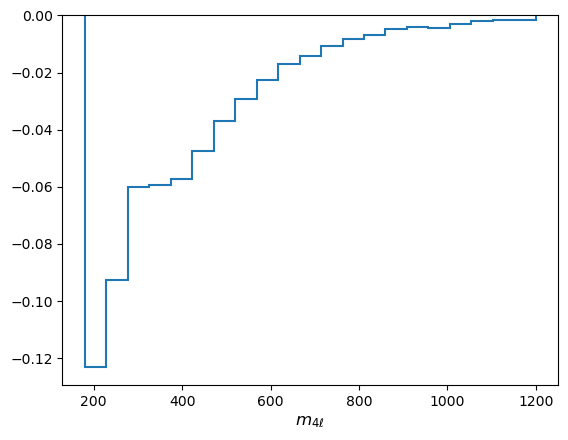

In [8]:
fig, ax = plt.subplots()

h_m4l_int = h_m4l_sbi - h_m4l_sig - h_m4l_bkg
h_m4l_int.plot(ax=ax)

ax.set_xlabel(r'$m_{4\ell}$', fontsize=12)

**Question for participants**

Does the above plot agree with your answers in the previous visualization? 

## 4. Modifications to Higgs process via signal strength

Modifications to the Higgs signal process is assumed to occur through the signal strength parameter, $\mu$, that scales the signal-squared & inteference terms as:

$$
\left| \sqrt{\mu} \mathcal{M}_{\rm S} + \mathcal{M}_{\rm B} \right|^2 = \mu |\mathcal{M}_{\rm S}|^2 + \sqrt{\mu} 2 \mathbb{R} ( \mathcal{M}^{\dagger}_{\rm S} \mathcal{M}_{\rm B} ) + \left| \mathcal{M}_{\rm B} \right|^2
$$

The code to calculate changes in the event weight of the full signal+background+interference process.

```py
mu = 1.0  # use a value other than 1!
w_sbi_bsm, _ = sigstr.scale(events_sbi, signal_strength = mu)
```

Notice that setting $\mu = 0.0$ generates a background-only sample from the full SBI process. Alternatively, setting $\mu=4.0$ should "scale up" the Higgs signal: let's check this for the $m_{4\ell}$ distribution. Try varying $\mu$ to see how the distribution changes. 

In [ ]:
mu = 4.0

fig, ax = plt.subplots()

w_sbi_mu4p0, _ = events_sbi_mu4p0 = sigstr.scale(events_sbi, signal_strength = mu)

h_m4l_sbi_mu4p0 = hist.Hist(m4l_axis)
h_m4l_sbi_mu4p0.fill( calculate_m4l(events_sbi.kinematics), weight = w_sbi_mu4p0)

h_m4l_bkg.plot(label='Background', color='grey', ax=ax)
h_m4l_sbi.plot(label='SBI (SM)', color='#6A93F5', ax=ax)
h_m4l_sbi_mu4p0.plot(label=rf'SBI ($\mu = ${mu})', color='#428A2E', ax=ax)

ax.set_yscale('log')
ax.set_xlabel(r'$m_{4\ell}$', fontsize=12)
ax.legend()

**Exercise**:

Use the above cell to explore various values of $\mu$

**Questions for participants**

1. What are your findings? 